In [4]:
import psycopg2

from sqlalchemy import create_engine, Column, Integer, String
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker

In [6]:
# setting parameters to connect to a database
db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group2',
    'password': 'blockd_2024group2_58'
}

In [34]:
# establishing a connection to the data base 
conn = psycopg2.connect(**db_params)

In [35]:
# creating a cursor
cursor = conn.cursor()

In [36]:
# 1.1 How many event categories are in the database?

# define sql query to select the categories from the safe_driving table
query = """ SELECT DISTINCT(TRIM(category)) from data_lake.safe_driving"""

# executing the query and fetch all records returned from the query 
cursor.execute(query)
record = cursor.fetchall()
print(record)

# close the connection
conn.close()

[('ACCELERATING',), ('BRAKING',), ('HARSH CORNERING',), ('SPEED',)]


In [6]:
# 1.2 On which date were there the most incidents of speeding?
conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

# define query for the start of the event with the total count of speeding incidents
# using the SPEED category from safe_driving, and grouping by the alias incidient_date and ordering by alias speeding_incidents in DESC order.
query = """ 
    SELECT DATE(event_start) AS incident_date, COUNT(*) AS speeding_incidents
    FROM data_lake.safe_driving
    WHERE category = 'SPEED'
    GROUP BY incident_date
    ORDER BY speeding_incidents DESC
    LIMIT 1;
    """

cursor.execute(query)

# Fetch the result
result = cursor.fetchone()

# unpacking results into variables for ease of use
date_with_most_speeding_incidents, count = result

#printing results
print(f"This is the date with the most incidents: {date_with_most_speeding_incidents}, with this many incidents happening: {count}")

# Close the cursor and connection
cursor.close()
conn.close()

This is the date with the most incidents: 2023-03-02, with this many incidents happening: 374


In [8]:
import psycopg2

# Assuming db_params is defined elsewhere with the appropriate connection parameters
conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query = """ 
    SELECT DATE(event_start) AS incident_date, COUNT(*) AS braking_incidents
    FROM data_lake.safe_driving
    WHERE category = 'HB'
    GROUP BY incident_date
    ORDER BY braking_incidents DESC
    LIMIT 1;
    """
cursor.execute(query)

result = cursor.fetchone()

if result:
    date_with_most_braking_incidents, count = result
    print(f"This is the date with the most incidents: {date_with_most_braking_incidents}, with this many incidents happening: {count}")
else:
    print("No hard braking incidents found.")

cursor.close()
conn.close()

No hard braking incidents found.


In [8]:
# As you can see there are no incidents of hard braking, so we will check for just BRAKING

conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query = """ 
    SELECT DATE(event_start) AS incident_date, COUNT(*) AS braking_incidents
    FROM data_lake.safe_driving
    WHERE category = 'BRAKING'
    GROUP BY incident_date
    ORDER BY braking_incidents DESC
    LIMIT 1;
    """
cursor.execute(query)

result = cursor.fetchone()

date_with_most_braking_incidents, count = result
print(f"This is the date with the most incidents: {date_with_most_speeding_incidents}, with this many incidents happening: {count}")

cursor.close()
conn.close()

This is the date with the most incidents: 2023-03-02, with this many incidents happening: 225


In [9]:
# 1.4 Which road name has the highest average speed for speeding incidents?

conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query = """ 
    SELECT(road_name) AS road_names, AVG(speed_kmh) AS average_speed
    FROM data_lake.safe_driving
    WHERE category = 'SPEED'
    GROUP BY road_names
    ORDER BY average_speed DESC
    LIMIT 1;
    """
cursor.execute(query)

# Fetch the result
result = cursor.fetchone()

road_name, average_speed = result
print(f"The road name with the highest average speed is: {road_name}, with an average speed of: {average_speed} kmh")

# Close the cursor and connection
cursor.close()
conn.close()

The road name with the highest average speed is: Scheldestraat, with an average speed of: 151.27833557128906 kmh


In [12]:
# 1.5 Which road name has the highest average speed for speeding incidents where more than 5 total incidents have occured?

conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query = """ 
    SELECT(road_name) AS road_names, AVG(speed_kmh) AS average_speed, COUNT(*) AS speeding_incidents
    FROM data_lake.safe_driving
    WHERE category = 'SPEED'
    GROUP BY road_names
    ORDER BY average_speed DESC
    LIMIT 1;
    """
cursor.execute(query)

# Fetch the result
result = cursor.fetchone()

road_name, average_speed, speeding_incidents = result
print(f"The road name with the highest average speed is: {road_name}, with an average speed of: {average_speed} kmh, with this many speeding incidents: {speeding_incidents}")

# Close the cursor and connection
cursor.close()
conn.close()

The road name with the highest average speed is: Scheldestraat, with an average speed of: 151.27833557128906 kmh, with this many speeding incidents: 5


In [13]:
## Section 2

In [24]:
# 2.1 Find the instance of Hard Braking where the highest G-Force was recorded. If there are multiple instances of the same G-Force chose the event with the largest difference in starting speed to ending speed.

conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query = """ 
    SELECT maxwaarde
    FROM data_lake.safe_driving
    WHERE category = 'BRAKING'
    ORDER BY maxwaarde DESC
    LIMIT 3;
    """
cursor.execute(query)

# Fetch the result
result = cursor.fetchall()

maxwaarde = result
print(f"The highest G-Force recorded is: {maxwaarde}")

# Close the cursor and connection
cursor.close()
conn.close()

# Since the first 3 are the same, I will do the other option in the next cell

The highest G-Force recorded is: [(10.18232,), (10.18232,), (10.18232,)]


In [6]:
conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query = """ 
    SELECT speed_kmh, end_speed_kmh, event_start, event_end, eventid
    FROM data_lake.safe_driving
    WHERE category = 'BRAKING'
    ORDER BY maxwaarde DESC, (speed_kmh - end_speed_kmh) DESC
    LIMIT 1;
"""
cursor.execute(query)

results = cursor.fetchall()

cursor.close()
conn.close()

for i, result in enumerate(results, start=1):
    speed_kmh, end_speed_kmh, event_start, event_end, eventid = result
    print(f"Event {i}:")
    print(f"  Event ID: {eventid}")
    print(f"  Event Start: {event_start}")
    print(f"  Event End: {event_end}")
    print(f"  Starting Speed: {speed_kmh} km/h")
    print(f"  Ending Speed: {end_speed_kmh} km/h")
    print()



Event 1:
  Event ID: 122613791
  Event Start: 2023-09-02 15:59:54.400000
  Event End: 2023-09-02 15:59:55.300000
  Starting Speed: 4.770007 km/h
  Ending Speed: 5.4036093 km/h



In [ ]:
# This one has the biggest difference in speed

In [18]:
# 2.2 Did it rain in the hour before this incident?

from datetime import datetime, timedelta

conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

# query to select precipitation 1 hour before the incident
query = """ 
    SELECT COUNT(*)
    FROM data_lake.precipitation
    WHERE dtg BETWEEN %s - INTERVAL '1 hour' AND %s
"""

# defining the start of the incident
incident_start_time = '2023-09-02 15:59:54.400000'

# converting into datetime object
incident_start_timestamp = datetime.strptime(incident_start_time, '%Y-%m-%d %H:%M:%S.%f')

cursor.execute(query, (incident_start_timestamp, incident_start_timestamp))

results = cursor.fetchone()

cursor.close()
conn.close()

rainfall_count = result[0]

if rainfall_count > 0:
    print("Yes, it rained in the hour before this incident.")
print(f"This is how many times there was rainfall before the incident: {rainfall_count}")


Yes, it rained in the hour before this incident.
This is how many times there was rainfall before the incident: 4.770007


In [7]:
# 2.3 What was the weather like on the day when there were the most speeding incidents? (Calculate Min and Max temperatures, total rain fall, average wind speed)

conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query_maxspeeding = """
    SELECT DATE(event_start) AS incident_date, COUNT(*) AS speeding_incidents
    FROM data_lake.safe_driving
    WHERE category = 'SPEED'
    GROUP BY incident_date
    ORDER BY speeding_incidents DESC
    LIMIT 1
"""

cursor.execute(query_maxspeeding)
maxspeeding, _ = cursor.fetchone()

query_weather = """
    SELECT *
    FROM data_lake.temperature
    JOIN data_lake.precipitation ON temperature.dtg = precipitation.dtg
    JOIN data_lake.wind ON temperature.dtg = wind.dtg
    WHERE DATE(temperature.dtg) = %s
"""

cursor.execute(query_weather, (maxspeeding,))
weather_data = cursor.fetchall()

# ectract data such as temps, rainfall and wind speeds
temperatures = [row[15] for row in weather_data if row[15] is not None]  # Assuming temperature is at index 15
rainfall_values = [row[8] for row in weather_data if row[8] is not None]  # Assuming rainfall is at index 8
wind_speeds = [row[8] for row in weather_data if row[8] is not None]  # Assuming wind speed is at index 8

# calculating min max temps, sum of rainfall and avg wind speed
min_temperature = min(temperatures) if temperatures else None
max_temperature = max(temperatures) if temperatures else None
total_rainfall = sum(rainfall_values)
average_wind_speed = sum(wind_speeds) / len(wind_speeds) if wind_speeds else None

print(f"On {maxspeeding}:")
print(f"Minimum Temperature: {min_temperature}°C")
print(f"Maximum Temperature: {max_temperature}°C")
print(f"Total Rainfall: {total_rainfall} mm")
print(f"Average Wind Speed: {average_wind_speed} m/s")

# Close the cursor and connection
cursor.close()
conn.close()

On 2023-03-02:
Minimum Temperature: None°C
Maximum Temperature: None°C
Total Rainfall: 315.80000000000007 mm
Average Wind Speed: 2.193055555555556 m/s


In [ ]:
# Section 3

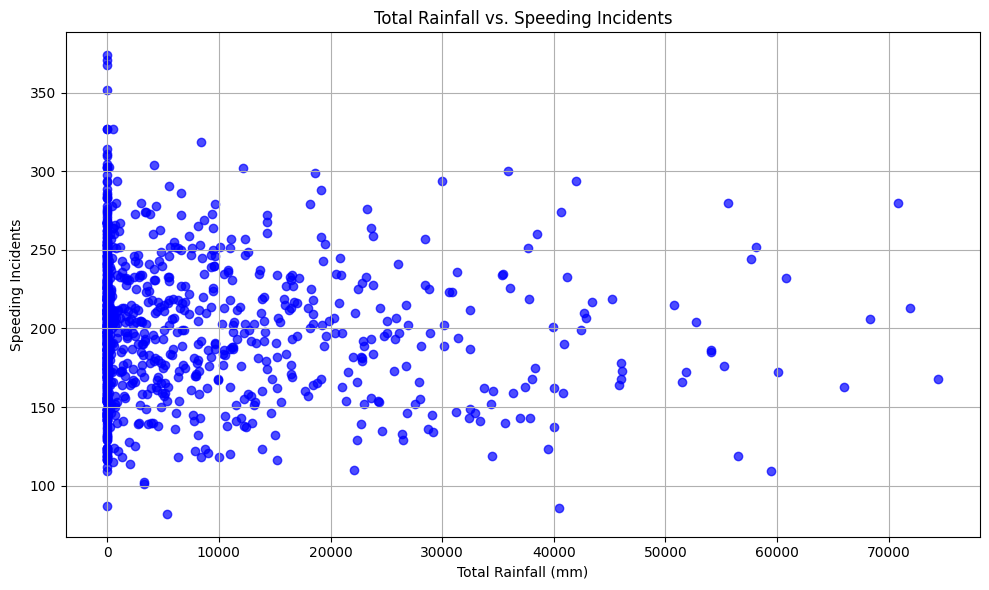

In [18]:
# 3.1 Plot the frequency of speeding incidents against the daily total rainfall.

import pandas as pd
import matplotlib.pyplot as plt

conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query_rainfall = """
    SELECT DATE(dtg) AS date, SUM(DR_REGENM_10) AS total_rainfall
    FROM data_lake.precipitation
    GROUP BY date
"""

cursor.execute(query_rainfall)
rainfall_data = cursor.fetchall()

query_speedingincidents = """
    SELECT DATE(event_start) AS date, COUNT(*) AS speeding_incidents
    FROM data_lake.safe_driving
    WHERE category = 'SPEED'
    GROUP BY date
"""

cursor.execute(query_speedingincidents)
speeding_incidents_data = cursor.fetchall()

cursor.close()
conn.close()

# create dfs from fetched data
df_rainfall = pd.DataFrame(rainfall_data, columns=['Date', 'Total Rainfall'])
df_speeding_incidents = pd.DataFrame(speeding_incidents_data, columns=['Date', 'Speeding Incidents'])

# merge dfs on the date column
df_merged = pd.merge(df_rainfall, df_speeding_incidents, on='Date', how='outer')

plt.figure(figsize=(10, 6))
plt.scatter(df_merged['Total Rainfall'], df_merged['Speeding Incidents'], color='blue', alpha=0.7)
plt.title('Total Rainfall vs. Speeding Incidents')
plt.xlabel('Total Rainfall (mm)')
plt.ylabel('Speeding Incidents')
plt.grid(True)
plt.tight_layout()
plt.show()

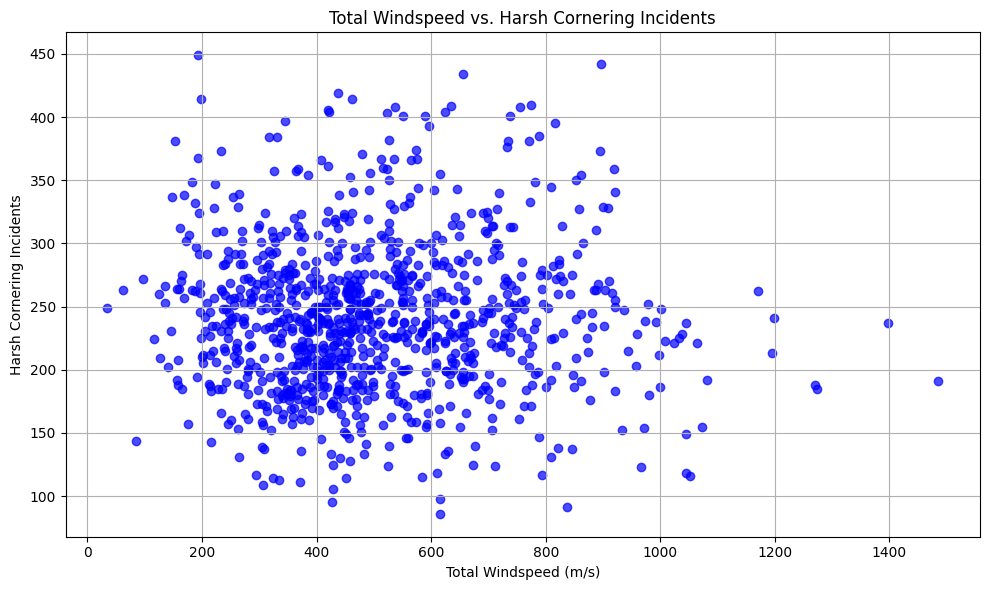

In [24]:
# 3.2 Plot the frequency of Harsh Cornering incidents against daily maximum windspeed.

conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

query_windspeed = """
    SELECT DATE(dtg) AS date, SUM(FF_10M_10) AS total_windspeed
    FROM data_lake.wind
    GROUP BY date
"""

cursor.execute(query_windspeed)
windspeed_data = cursor.fetchall()

query_harshcornering = """
    SELECT DATE(event_start) AS date, COUNT(*) AS harsh_cornering
    FROM data_lake.safe_driving
    WHERE category = 'HARSH CORNERING'
    GROUP BY date
"""

cursor.execute(query_harshcornering)
harsh_cornering_data = cursor.fetchall()

cursor.close()
conn.close()

df_wind = pd.DataFrame(windspeed_data, columns=['Date', 'Total Windspeed'])
df_hc = pd.DataFrame(harsh_cornering_data, columns=['Date', 'Harsh Cornering Incidents'])

df_merged = pd.merge(df_wind, df_hc, on='Date', how='outer')

plt.figure(figsize=(10, 6))
plt.scatter(df_merged['Total Windspeed'], df_merged['Harsh Cornering Incidents'], color='blue', alpha=0.7)
plt.title('Total Windspeed vs. Harsh Cornering Incidents')
plt.xlabel('Total Windspeed (m/s)')
plt.ylabel('Harsh Cornering Incidents')
plt.grid(True)
plt.tight_layout()
plt.show()